In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

df = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")

mapping = {}
cols = df.select_dtypes(include=["object"]).columns
for col in df.columns:
    if col in cols:
        df[col] = df[col].fillna(df[col].mode()[0])
        unique_vals = df[col].unique()
        mpp = {val: i for i, val in enumerate(unique_vals)}
        df[col] = df[col].map(mpp)
        mapping[col] = mpp
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].mean())

In [16]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=["id"], errors="ignore")

df['age'] = pd.cut(df['age'], bins=5, labels=False)
df['avg_glucose_level'] = pd.cut(df['avg_glucose_level'], bins=5, labels=False)
df['bmi'] = pd.cut(df['bmi'], bins=5, labels=False)

X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [17]:
X_train_stroke_1 = X_train[y_train == 1].sample(n=100, random_state=42)
X_train_stroke_0 = X_train[y_train == 0].sample(n=100, random_state=42)
X_train_bal = pd.concat([X_train_stroke_1, X_train_stroke_0])
y_train_bal = pd.Series([1]*100 + [0]*100)

In [18]:
df_train = X_train.copy()
df_train['stroke'] = y_train
stroke_1 = df_train[df_train['stroke'] == 1].sample(n=100, random_state=42)
stroke_0 = df_train[df_train['stroke'] == 0].sample(n=100, random_state=42)
df_train_bal = pd.concat([stroke_1, stroke_0]).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_bal = df_train_bal.drop('stroke', axis=1)
y_train_bal = df_train_bal['stroke']


In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_bal, y_train_bal)
X_test_lda = lda.transform(X_test)

X_train_lda_bin = pd.cut(X_train_lda.flatten(), bins=10, labels=False)
X_test_lda_bin = pd.cut(X_test_lda.flatten(), bins=10, labels=False)

df_train_lda = pd.DataFrame({'lda_bin': X_train_lda_bin, 'stroke': y_train_bal})
df_test_lda = pd.DataFrame({'lda_bin': X_test_lda_bin, 'stroke': y_test})

stroke_counts = Counter(df_train_lda['stroke'])
prior_probabilities = {k: v / len(df_train_lda) for k, v in stroke_counts.items()}


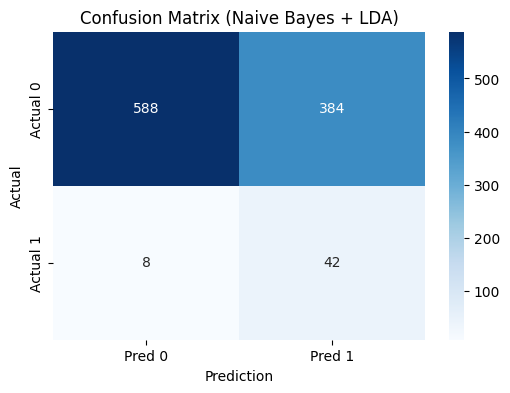

Accuracy: 0.6164

Classification Report:
              precision    recall  f1-score   support

           0     0.9866    0.6049    0.7500       972
           1     0.0986    0.8400    0.1765        50

    accuracy                         0.6164      1022
   macro avg     0.5426    0.7225    0.4632      1022
weighted avg     0.9431    0.6164    0.7219      1022



In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Likelihoods
laplace_likelihoods = {}
for label in [0, 1]:
    subset = df_train_lda[df_train_lda['stroke'] == label]
    counts = Counter(subset['lda_bin'])
    total = len(subset) + 10  # 10 bins
    laplace_likelihoods[label] = {bin_: (counts.get(bin_, 0) + 1) / total for bin_ in range(10)}

# Posterior
def predict_lda(bin_val, threshold=0.5, return_prob=False):
    log_probs = {}
    for label in [0, 1]:
        prior = math.log(prior_probabilities[label])
        likelihood = math.log(laplace_likelihoods[label].get(bin_val, 1 / (len(df_train_lda) + 10)))
        log_probs[label] = prior + likelihood

    max_log = max(log_probs.values())
    probs = {k: math.exp(v - max_log) for k, v in log_probs.items()}
    total_prob = sum(probs.values())
    normalized = {k: v / total_prob for k, v in probs.items()}

    if return_prob:
        return normalized[1]  # Probability of class 1
    return 1 if normalized[1] >= threshold else 0


# Predict
df_test_lda['Predicted'] = df_test_lda['lda_bin'].apply(lambda x: predict_lda(x, threshold=0.4))

# Evaluate
conf_matrix = confusion_matrix(df_test_lda['stroke'], df_test_lda['Predicted'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Naive Bayes + LDA)")
plt.show()

print(f"Accuracy: {accuracy_score(df_test_lda['stroke'], df_test_lda['Predicted']):.4f}")
print("\nClassification Report:")
print(classification_report(df_test_lda['stroke'], df_test_lda['Predicted'], digits=4))


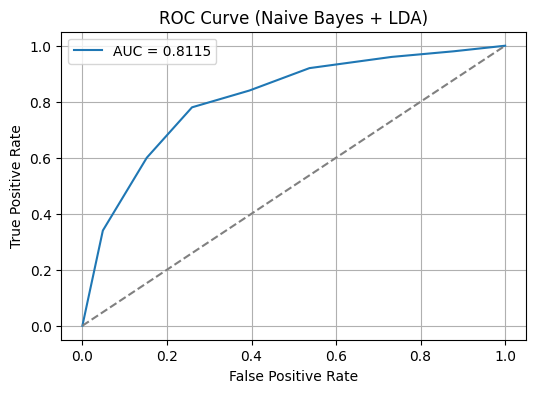

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

df_test_lda['Prob_1'] = df_test_lda['lda_bin'].apply(lambda x: predict_lda(x, return_prob=True))
df_test_lda['Predicted'] = df_test_lda['Prob_1'].apply(lambda p: 1 if p >= 0.4 else 0)

fpr, tpr, thresholds = roc_curve(df_test_lda['stroke'], df_test_lda['Prob_1'])
auc_score = roc_auc_score(df_test_lda['stroke'], df_test_lda['Prob_1'])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Naive Bayes + LDA)")
plt.legend()
plt.grid(True)
plt.show()
